<a href="https://colab.research.google.com/github/Attia324/ML_Models_Practise/blob/main/student_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import pandas for data manipulations
import pandas as pd

#import numpy for numerical operations
import numpy as np

#seaborn and matplotlib for data visuallization
import seaborn as sns
import matplotlib.pyplot as plt

#date time for time series data
from datetime import datetime

#to avoid warnings
import warnings
warnings.filterwarnings("ignore")

#setting style for visuallization
try:
   plt.style.use("seaborn-v0_8-darkgrid")
except:
    try:
        plt.style.use("seaborn-darkgrid")
    except:
        plt.style.use("ggplot")


sns.set_palette('husl')

#Display settings
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)
pd.set_option("display.float_format", lambda x : "%.2f" % x)

In [ ]:
df=pd.read_csv('/content/student_performance_dataset.csv')

## The Basic Overview of dataset

In [ ]:
print(f" Our dataset contain {df.shape[0]} rows and {df.shape[1]} columns")
# Null values  detection
print(df.isnull().sum())

 Our dataset contain 3000 rows and 32 columns
student_id                      0
age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours             60
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
bu

In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'city_type', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index',
       'mental_state', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'learning_style', 'career_goal',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score', 'performance_category'],
      dtype='object')

In [ ]:
df.head(5)

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,stress_level,motivation_level,focus_score,procrastination_index,mental_state,sleep_hours,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.20,7,100,70,3.80,0,107,0.60,1.80,8,5,4.00,8,Balanced,5.80,4,0.60,1,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.90,2,46,70,2.60,1,93,1.50,1.10,4,7,8.00,3,Burnout,6.10,5,0.00,4,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.30,7,54,57,4.30,1,82,0.50,0.00,2,5,8.00,10,Burnout,6.60,4,1.30,9,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.30,1,78,90,1.70,0,27,1.40,3.80,8,6,3.00,1,Burnout,8.00,2,1.30,1,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.10,3,100,81,2.60,0,8,1.30,2.50,4,7,3.00,6,Focused,6.90,5,1.70,9,5,6,Visual,Medical,4,10,7,9,77,High


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

In [ ]:
duplicates = df[df.duplicated()]

In [ ]:
duplicates.shape

(0, 32)

In [ ]:
df = df.drop(columns=["student_id"])

In [ ]:
df.dtypes

,0
age,int64
gender,object
city_type,object
study_hours_per_day,float64
deep_work_sessions,int64
assignment_completion_rate,int64
attendance_percentage,int64
social_media_hours,float64
doomscrolling_before_sleep,int64
notification_distractions,int64


In [ ]:
df.select_dtypes(include=['object']).columns

Index(['gender', 'city_type', 'mental_state', 'learning_style', 'career_goal',
       'performance_category'],
      dtype='object')

In [ ]:
df.select_dtypes(include=["int64","float64"]).columns

Index(['age', 'study_hours_per_day', 'deep_work_sessions',
       'assignment_completion_rate', 'attendance_percentage',
       'social_media_hours', 'doomscrolling_before_sleep',
       'notification_distractions', 'ai_tool_usage_hours', 'gaming_hours',
       'stress_level', 'motivation_level', 'focus_score',
       'procrastination_index', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'productivity_after_midnight',
       'revision_efficiency', 'burnout_risk', 'consistency_score',
       'final_exam_score'],
      dtype='object')

In [ ]:
df=df.dropna()

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
city_type,0
study_hours_per_day,0
deep_work_sessions,0
assignment_completion_rate,0
attendance_percentage,0
social_media_hours,0
doomscrolling_before_sleep,0
notification_distractions,0


In [ ]:
numeric_df=df.select_dtypes(include=["int64","float64"])

In [ ]:
(numeric_df<0).sum()

,0
age,0
study_hours_per_day,0
deep_work_sessions,0
assignment_completion_rate,0
attendance_percentage,0
social_media_hours,0
doomscrolling_before_sleep,0
notification_distractions,0
ai_tool_usage_hours,0
gaming_hours,0


In [ ]:
df.describe()

,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,stress_level,motivation_level,focus_score,procrastination_index,sleep_hours,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00
mean,19.03,4.00,3.51,70.03,74.50,2.94,0.50,61.87,1.55,2.05,5.56,5.54,5.50,5.58,6.51,3.51,1.06,5.52,5.48,5.58,5.55,5.43,5.53,5.53,54.82
std,2.56,1.50,2.29,17.58,14.46,1.51,0.50,33.11,0.93,1.38,2.89,2.86,2.86,2.88,1.20,2.28,0.73,2.91,2.86,2.86,2.86,2.89,2.84,2.86,18.72
min,15.00,0.50,0.00,40.00,50.00,0.00,0.00,5.00,0.00,0.00,1.00,1.00,1.00,1.00,3.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00
25%,17.00,2.90,1.00,55.00,62.00,1.90,0.00,32.00,0.90,0.90,3.00,3.00,3.00,3.00,5.70,2.00,0.50,3.00,3.00,3.00,3.00,3.00,3.00,3.00,42.00
50%,19.00,4.00,4.00,70.00,74.00,2.90,0.00,62.00,1.50,2.00,6.00,6.00,5.00,6.00,6.50,3.00,1.00,6.00,5.00,6.00,6.00,5.00,6.00,6.00,55.00
75%,21.00,5.00,6.00,85.00,87.00,4.00,1.00,91.00,2.20,3.00,8.00,8.00,8.00,8.00,7.30,5.00,1.60,8.00,8.00,8.00,8.00,8.00,8.00,8.00,67.50
max,23.00,8.80,7.00,100.00,100.00,8.90,1.00,119.00,5.00,7.00,10.00,10.00,10.00,10.00,10.00,7.00,3.90,10.00,10.00,10.00,10.00,10.00,10.00,10.00,100.00


In [ ]:
X=df.drop("final_exam_score",axis=1)
y=df["final_exam_score"]

In [ ]:

from sklearn .model_selection  import train_test_split

X_train,  X_test,   y_train,  y_test  = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.head()

,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,stress_level,motivation_level,focus_score,procrastination_index,mental_state,sleep_hours,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,performance_category
981,21,Female,Urban,2.40,0,91,94,1.00,1,53,2.50,0.70,7,10,4.00,8,Distracted,4.30,2,0.70,10,4,9,Audio,Arts,4,4,8,8,Low
2343,22,Female,Rural,4.90,4,48,87,0.10,1,112,2.20,1.20,8,5,10.00,9,Distracted,6.40,5,0.10,1,6,1,Practical,Arts,5,3,10,10,Medium
823,19,Female,Semi-Urban,5.00,4,84,95,3.10,0,72,1.30,2.50,4,4,3.00,8,Burnout,6.50,3,1.40,4,6,8,Visual,Business,6,6,10,4,Low
729,17,Female,Semi-Urban,2.70,4,73,66,1.90,0,83,0.00,0.60,9,9,6.00,2,Focused,6.40,0,0.70,5,2,4,Practical,Business,3,5,6,7,Medium
1089,19,Male,Urban,2.80,5,63,100,3.90,1,25,1.50,0.50,8,5,3.00,1,Balanced,8.50,6,0.80,10,8,3,Audio,Business,10,9,3,4,Medium


#We will apply one *hot encoding* to all of thse columns
### 'gender', 'city_type', 'mental_state', 'learning_style', 'career_goal
#and label encoding to  
### 'performance_category'

In [ ]:


# Apply one Hot Encoding to  'gender', 'city_type', 'mental_state', 'learning_style', 'career_goal'
X_train_df=pd.get_dummies(X_train,columns=['gender', 'city_type', 'mental_state', 'learning_style', 'career_goal'])
X_train_df.shape

from sklearn.preprocessing import OneHotEncoder,LabelEncoder
le=LabelEncoder()
cols = ["performance_category"]

# Apply label encoding
X_train_df[cols]=X_train_df[cols].apply(le.fit_transform)

In [ ]:
X_train_df.shape

(2258, 43)

# Apply Encoding to the test dataset

In [ ]:
# Apply one Hot Encoding to  'gender', 'city_type', 'mental_state', 'learning_style', 'career_goal'
X_test_df=pd.get_dummies(X_test,columns=['gender', 'city_type', 'mental_state', 'learning_style', 'career_goal'])
X_test_df.shape

from sklearn.preprocessing import OneHotEncoder,LabelEncoder
le=LabelEncoder()
cols = ["performance_category"]

# Apply label encoding
X_test_df[cols]=X_test_df[cols].apply(le.fit_transform)

In [ ]:
X_test_df.shape

(565, 43)

# Apply Scalling  on dataset

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scale_X_train=scaler.fit_transform(X_train_df)
scale_X_test=scaler.fit_transform(X_test_df)

#Train  a Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(scale_X_train,y_train)

LinearRegression()

In [ ]:
# Step 1: Sab se pehle sklearn se zaroori metrics ko import karein
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 2: Test data (X_test) par predictions generate karein
# (Yahan 'model' aap ke trained Linear Regression model ka naam hai)
y_pred = model.predict(scale_X_test)

# Agar aap train data ka score bhi check karna chahti hain (Overfitting dekhne ke liye):
y_train_pred = model.predict(scale_X_train)


# Step 3: Metrics calculate aur print karein

print("=== MODEL EVALUATION RESULTS ===")

# 1. R-squared Score (Train aur Test dono ka)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)
print(f"R2 Score (Training Data): {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"R2 Score (Testing Data): {r2_test:.4f} ({r2_test*100:.2f}%)")

# 2. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f} marks")

# 3. Root Mean Squared Error (RMSE) - Yeh bhi bohot use hota hai
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} marks")


# Step 4: Ek random student ka Actual vs Predicted score check karein
print("\n=== RANDOM PREDICTION CHECK ===")
# Pehle 5 students ka comparison dekhne ke liye:
for i in range(5):
    print(f"Student {i+1} -> Actual Score: {list(y_test)[i]:.2f} | Predicted Score: {y_pred[i]:.2f}")

=== MODEL EVALUATION RESULTS ===
R2 Score (Training Data): 0.8118 (81.18%)
R2 Score (Testing Data): 0.8156 (81.56%)
Mean Absolute Error (MAE): 6.44 marks
Root Mean Squared Error (RMSE): 8.25 marks

=== RANDOM PREDICTION CHECK ===
Student 1 -> Actual Score: 23.00 | Predicted Score: 23.32
Student 2 -> Actual Score: 86.00 | Predicted Score: 80.25
Student 3 -> Actual Score: 62.00 | Predicted Score: 47.94
Student 4 -> Actual Score: 76.00 | Predicted Score: 67.33
Student 5 -> Actual Score: 63.00 | Predicted Score: 59.10


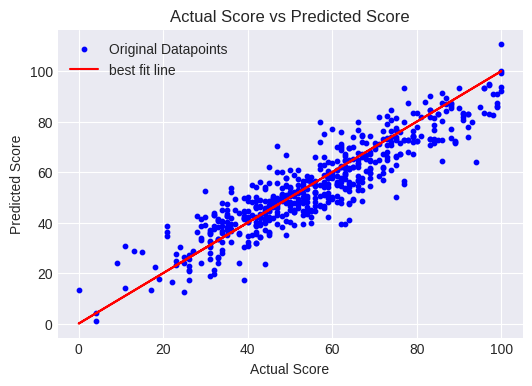

In [ ]:

y_pred=model.predict(scale_X_test)
plt.figure(figsize=(6,4))
plt.scatter(y_test,y_pred,color="blue",marker="o",s=10,label="Original Datapoints")
plt.plot(y_test,y_test,color="red",label="best fit line")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual Score vs Predicted Score")
plt.legend()
plt.show()

In [ ]:
(X_train_df.columns)

Index(['age', 'study_hours_per_day', 'deep_work_sessions',
       'assignment_completion_rate', 'attendance_percentage',
       'social_media_hours', 'doomscrolling_before_sleep',
       'notification_distractions', 'ai_tool_usage_hours', 'gaming_hours',
       'stress_level', 'motivation_level', 'focus_score',
       'procrastination_index', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'productivity_after_midnight',
       'revision_efficiency', 'burnout_risk', 'consistency_score',
       'performance_category', 'gender_Female', 'gender_Male',
       'city_type_Rural', 'city_type_Semi-Urban', 'city_type_Urban',
       'mental_state_Balanced', 'mental_state_Burnout',
       'mental_state_Distracted', 'mental_state_Focused',
       'learning_style_Audio', 'learning_style_Practical',
       'learning_style_Reading', 'learning_style_Visual', 'career_goal_Arts',
       'career_goal_Business', 'career_go

In [ ]:
len(model.coef_)

43

=== FEATURE IMPORTANCE (COEFFICIENTS) ===
                        Feature  Coefficient (Weight)
0             consistency_score                  6.02
1           study_hours_per_day                  5.98
2                   focus_score                  5.67
3           revision_efficiency                  4.21
4              motivation_level                  4.02
5    assignment_completion_rate                  3.54
6          mental_state_Focused                  3.54
7         attendance_percentage                  2.96
8            deep_work_sessions                  2.07
9                   sleep_hours                  1.92
10        mental_state_Balanced                  0.52
11      physical_activity_hours                  0.25
12               family_support                  0.22
13      mental_state_Distracted                  0.18
14       learning_style_Reading                  0.16
15         career_goal_Business                  0.13
16         city_type_Semi-Urban         

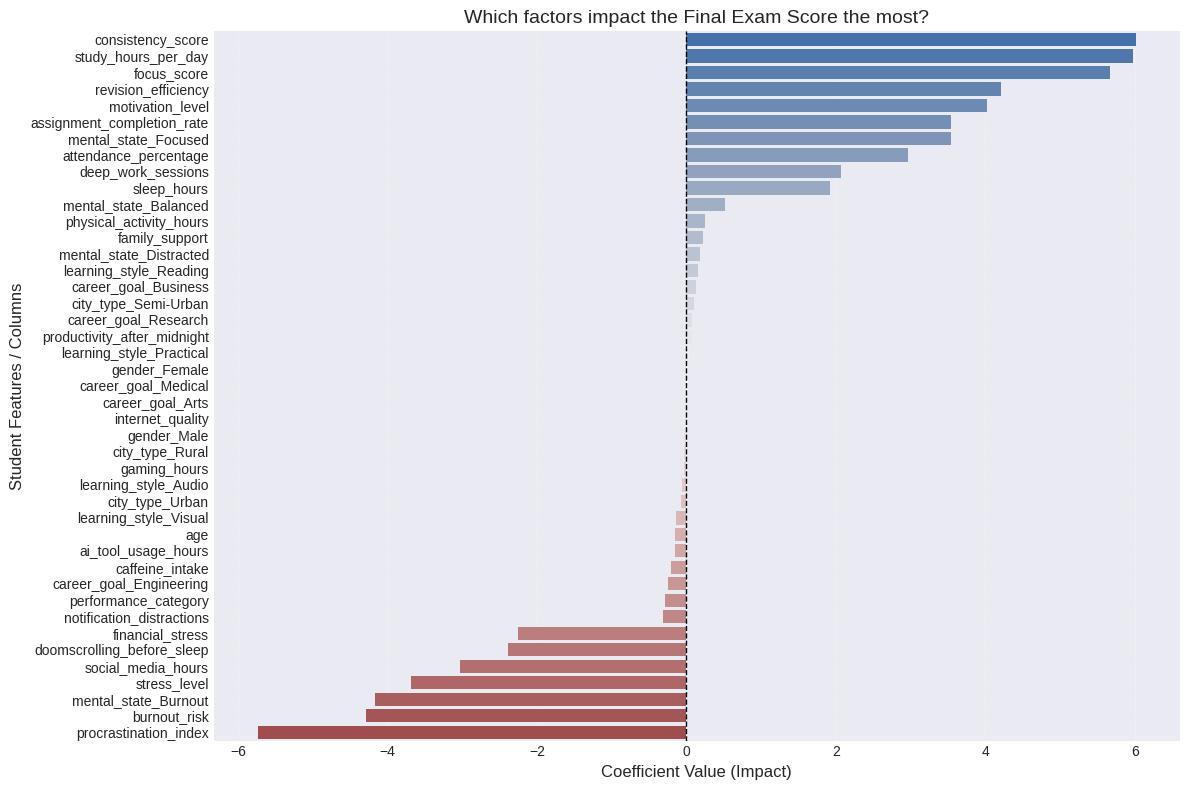

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1:  Create a Dataframe of Features and their  cofficients
feature_names = X_train_df.columns
coefficients = model.coef_


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient (Weight)': coefficients
})

# Sorting the  Coefficients from highest to lowest
importance_df = importance_df.sort_values(by='Coefficient (Weight)', ascending=False).reset_index(drop=True)

print("=== FEATURE IMPORTANCE (COEFFICIENTS) ===")
print(importance_df)


# Step 2:  Plot a grapg  of  these coefficients
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Coefficient (Weight)',
    y='Feature',
    data=importance_df,
    palette='vlag' # It will display positive with blue and negativ with red

plt.title('Which factors impact the Final Exam Score the most?', fontsize=14)
plt.xlabel('Coefficient Value (Impact)', fontsize=12)
plt.ylabel('Student Features / Columns', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) #  Draw a line on zero
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()